# Causal Forecasting with pgmpy: A Beginner's Guide

In this notebook, we'll demonstrate how to use `pgmpy` to model simple causal relationships in a retail setting. This is especially useful as a foundation for **time series forecasting** where understanding cause-effect relationships helps build better predictive models.

We'll use:
- A synthetic dataset (`Holiday`, `Ad_Spend`, `Sales`)
- A causal graph to define dependencies
- `pgmpy`'s `DiscreteBayesianNetwork` to model relationships
- Inference to simulate “what-if” scenarios


## Install and Import Libraries

In [10]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator
from pgmpy.inference import VariableElimination



## Simulate a Small Retail Dataset

In [6]:
np.random.seed(42)
n = 100

data = pd.DataFrame({
    'Holiday': np.random.binomial(1, 0.3, n),
    'Ad_Spend': np.random.randint(100, 300, size=n),
})

# Simulate sales with causal influence
data['Sales'] = (
    50 +
    100 * data['Holiday'] +
    0.8 * data['Ad_Spend'] +
    np.random.normal(0, 10, n)
).astype(int)

data.head()

,Holiday,Ad_Spend,Sales
0,0,162,187
1,1,195,310
2,1,151,259
3,0,195,199
4,0,231,243


## Visualize the Data

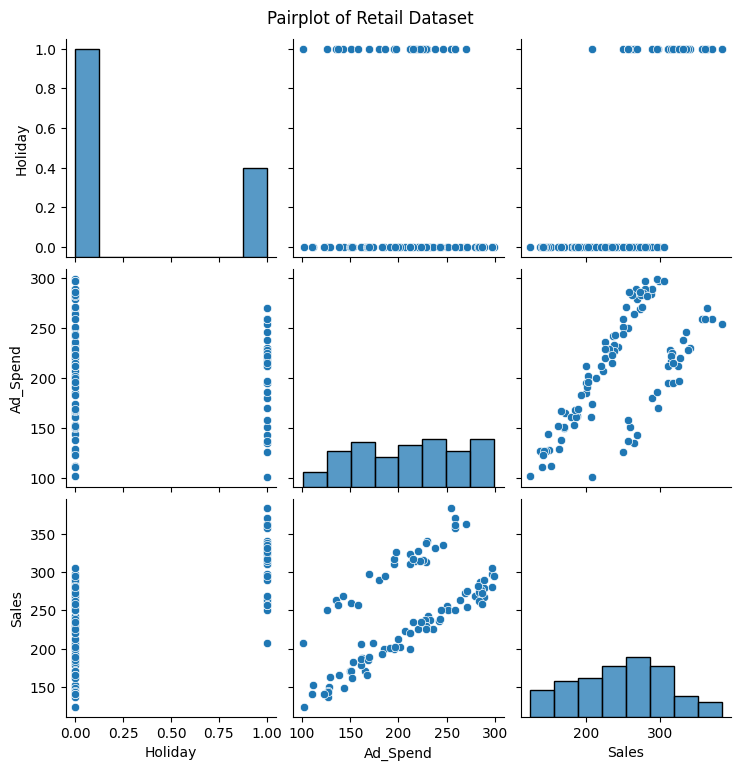

In [8]:
sns.pairplot(data)
plt.suptitle("Pairplot of Retail Dataset", y=1.02)
plt.show()

## Defining the Causal Graph

In [11]:
# Define the causal relationships
model = DiscreteBayesianNetwork([
    ('Holiday', 'Sales'),
    ('Ad_Spend', 'Sales')
])

## Fitting Model

In [12]:
from pgmpy.estimators import BayesianEstimator
from pgmpy.inference import VariableElimination

model.fit(data, estimator=BayesianEstimator, prior_type='BDeu')
inference = VariableElimination(model)


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered,O=Categorical Ordered)inferred from data: 
 {'Holiday': 'N', 'Ad_Spend': 'N', 'Sales': 'N'}


## Query-1: What Happens to Sales if Holiday = 1?

In [17]:
q1 = inference.query(variables=['Sales'], evidence={'Holiday': 1})
print("Distribution of Sales when Holiday = 1:\n")
print(q1)

Distribution of Sales when Holiday = 1:

╒════════════╤══════════════╕
│ Sales      │   phi(Sales) │
╞════════════╪══════════════╡
│ Sales(124) │       0.0080 │
├────────────┼──────────────┤
│ Sales(137) │       0.0080 │
├────────────┼──────────────┤
│ Sales(140) │       0.0080 │
├────────────┼──────────────┤
│ Sales(141) │       0.0080 │
├────────────┼──────────────┤
│ Sales(143) │       0.0080 │
├────────────┼──────────────┤
│ Sales(145) │       0.0080 │
├────────────┼──────────────┤
│ Sales(148) │       0.0080 │
├────────────┼──────────────┤
│ Sales(150) │       0.0080 │
├────────────┼──────────────┤
│ Sales(152) │       0.0080 │
├────────────┼──────────────┤
│ Sales(161) │       0.0080 │
├────────────┼──────────────┤
│ Sales(163) │       0.0080 │
├────────────┼──────────────┤
│ Sales(166) │       0.0080 │
├────────────┼──────────────┤
│ Sales(170) │       0.0080 │
├────────────┼──────────────┤
│ Sales(171) │       0.0080 │
├────────────┼──────────────┤
│ Sales(179) │       0.0080 │

P(Sales = 124 | Holiday = 1) = 0.0080

This is the conditional probability that Sales will be exactly 124 given that it's a holiday (i.e., Holiday = 1), according to the Bayesian model learned from our data.

In [ ]:
# validation
query_result = inference.query(variables=['Sales'], evidence={'Holiday': 1})
print(sum(query_result.values))

0.9999999999999997


## Query-2: What Happens if Ad_Spend = 250? 

In [18]:
q2 = inference.query(variables=['Sales'], evidence={'Ad_Spend': 250})
print("Distribution of Sales when Ad_Spend = 250:\n")
print(q2)

Distribution of Sales when Ad_Spend = 250:

╒════════════╤══════════════╕
│ Sales      │   phi(Sales) │
╞════════════╪══════════════╡
│ Sales(124) │       0.0042 │
├────────────┼──────────────┤
│ Sales(137) │       0.0042 │
├────────────┼──────────────┤
│ Sales(140) │       0.0042 │
├────────────┼──────────────┤
│ Sales(141) │       0.0042 │
├────────────┼──────────────┤
│ Sales(143) │       0.0042 │
├────────────┼──────────────┤
│ Sales(145) │       0.0042 │
├────────────┼──────────────┤
│ Sales(148) │       0.0042 │
├────────────┼──────────────┤
│ Sales(150) │       0.0042 │
├────────────┼──────────────┤
│ Sales(152) │       0.0042 │
├────────────┼──────────────┤
│ Sales(161) │       0.0042 │
├────────────┼──────────────┤
│ Sales(163) │       0.0042 │
├────────────┼──────────────┤
│ Sales(166) │       0.0042 │
├────────────┼──────────────┤
│ Sales(170) │       0.0042 │
├────────────┼──────────────┤
│ Sales(171) │       0.0042 │
├────────────┼──────────────┤
│ Sales(179) │       0.004

P(Sales = 124 | Add_Spend = 250) = 0.0042

This is the conditional probability that Sales will be exactly 124 given that Add_Spend will be around 250, according to the Bayesian model learned from our data.

## Query3: Joint Effect (Holiday = 1 and Ad_Spend = 250) 

In [19]:
q3 = inference.query(variables=['Sales'], evidence={'Holiday': 1, 'Ad_Spend': 250})
print("Distribution of Sales when Holiday = 1 and Ad_Spend = 250:\n")
print(q3)

Distribution of Sales when Holiday = 1 and Ad_Spend = 250:

╒════════════╤══════════════╕
│ Sales      │   phi(Sales) │
╞════════════╪══════════════╡
│ Sales(124) │       0.0125 │
├────────────┼──────────────┤
│ Sales(137) │       0.0125 │
├────────────┼──────────────┤
│ Sales(140) │       0.0125 │
├────────────┼──────────────┤
│ Sales(141) │       0.0125 │
├────────────┼──────────────┤
│ Sales(143) │       0.0125 │
├────────────┼──────────────┤
│ Sales(145) │       0.0125 │
├────────────┼──────────────┤
│ Sales(148) │       0.0125 │
├────────────┼──────────────┤
│ Sales(150) │       0.0125 │
├────────────┼──────────────┤
│ Sales(152) │       0.0125 │
├────────────┼──────────────┤
│ Sales(161) │       0.0125 │
├────────────┼──────────────┤
│ Sales(163) │       0.0125 │
├────────────┼──────────────┤
│ Sales(166) │       0.0125 │
├────────────┼──────────────┤
│ Sales(170) │       0.0125 │
├────────────┼──────────────┤
│ Sales(171) │       0.0125 │
├────────────┼──────────────┤
│ Sales(17

P(Sales = s | Holiday = 1, Ad_Spend = 250)

This is the conditional probability that Sales will take a specific value s (e.g., "High", "Medium", "Low") given that:

It is a holiday (Holiday = 1), and

The ad spend is 250 units.

The Discrete Bayesian Network uses this joint evidence to infer how likely each possible Sales value is under those conditions.

## 🔍 Discussion

- When `Holiday = 1`, the `Sales` distribution shifts higher, showing a clear causal link between holidays and retail sales.
- When `Ad_Spend = 250`, we also observe an upward shift in the `Sales` probability.
- When both are true, the effect compounds — reflecting how marketing efforts perform better during holidays.

This illustrates how we can answer **"what-if"** questions with causal models, something traditional ML forecasting tools don't easily offer.


## ✅ Conclusion

In this notebook, we:

- Created a synthetic retail dataset with causal dependencies
- Built a Discrete Bayesian Network using `pgmpy`
- Used probabilistic inference to answer causal queries

🎯 This demo acts as a **template** for how `pgmpy` can support **causal modeling for time series forecasting** — an area with growing importance and real-world value.

You can now open an issue and submit this as a contribution to `pgmpy` to help bridge causal inference and time series analysis!
